In [1]:
import pandas as pd
import matplotlib.pyplot as plt

data = pd.read_json("reels_data.json")

In [2]:
data['has_error'] = data['result'].apply(lambda x: not bool(x.get('verdict', False)))

In [3]:
without_error = data[data['has_error'] == False]

<Axes: title={'center': 'Distribution of Verdicts for Reels'}>

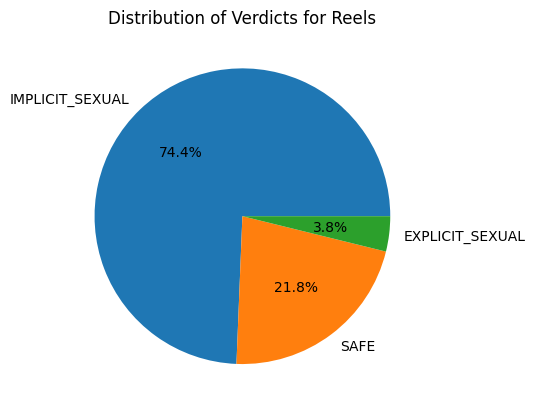

In [25]:
without_error.result.apply(lambda x: x.get('verdict', False)).value_counts().plot(kind='pie', title="Distribution of Verdicts for Reels", autopct='%1.1f%%')

In [5]:
implicit = without_error[without_error['dataset'] == True]

In [6]:
len(implicit) / len(without_error)

0.7435897435897436

In [7]:
data['ground_truth'] = None

In [16]:
from IPython.display import display, Video, clear_output

for idx, row in implicit.iterrows():
    display(Video(row['path']))
    data.loc[idx, 'ground_truth'] = input("Enter ground truth for this reel (i/s): ")
    clear_output(wait=True)

In [20]:
hit_rate = data.ground_truth.value_counts()['i'] / data.ground_truth.value_counts().sum()

print(f"Hit Rate: {hit_rate:.2%}")

Hit Rate: 77.59%


In [22]:
45 / len(without_error)

0.5769230769230769

In [26]:
45/87

0.5172413793103449

In [27]:
len(without_error)

78

In [28]:
45/78

0.5769230769230769

In [29]:
len(implicit)

58

In [30]:
45/58

0.7758620689655172